# AS cluster ranking across samples

Этот ноутбук собирает в одном месте старую rheum-логику:
- AS-клоны размечаются по точному совпадению со списком `as_seqs`.
- Volcano строятся по каждому образцу с отдельным цветом для кластеров, где есть `as_pattern`.
- Кластеры между образцами можно объединять по общему CDR3 или по одной замене: `MERGE_SUBSTITUTIONS=0/1`.
- После merge считаются summary-метрики, Fisher p-value и TOPSIS-рэнкинг.
- Для top-кластеров рисуются logo-плоты с подписью по V/J генам.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from as_cluster_ranking_helpers import (
    DEFAULT_AS_SEQS,
    annotate_run_volcano_summary,
    build_reference_matcher,
    build_sequence_patient_lookup_from_airr,
    load_many_runs,
    merge_clusters_by_cdr3_threshold,
    plot_ranked_metrics,
    plot_sample_volcano_grid,
    plot_top_cluster_logos,
    prepare_merged_clonotypes,
    rank_clusters_with_topsis,
    summarize_merged_clusters,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)


In [2]:
RUNS_ROOT = Path("/projects/immunestatus/rheum/redcea/runs")
AIRR_DIR = Path("/projects/immunestatus/rheum/airr_format")
METADATA_PATH = AIRR_DIR / "metadata.tsv"
CASE_SAMPLE_NAMES = sorted([
    path.name
    for path in RUNS_ROOT.iterdir()
    if path.is_dir() and path.name.startswith("as_")
])
CONTROL_SAMPLE_NAMES = sorted([
    path.name
    for path in RUNS_ROOT.iterdir()
    if path.is_dir() and (path.name.startswith("h_") or path.name.startswith("hd_"))
])
ALL_SAMPLE_NAMES = CASE_SAMPLE_NAMES + CONTROL_SAMPLE_NAMES

# AS reference; exact match only, without substitutions
AS_SEQS = DEFAULT_AS_SEQS
AS_MATCH_THRESHOLD = 0

# 0 = старый strict merge по общему CDR3, 1 = merge по одной замене
MERGE_SUBSTITUTIONS = 0

CASE_REGEX = r"^as_"
CONTROL_REGEX = r"^(?:h_|hd_)"

COMPUTE_PGEN_IF_MISSING = False
PGEN_PROCESSES = 16

TOPSIS_METRICS = {
    "sample_fraction": "benefit",
    "as_usage": "benefit",
    "h_usage": "cost",
    "log_pgen": "cost",
    "patient_fc": "benefit",
    "log_cluster_size": "benefit",
}

TOPSIS_WEIGHTS = {
    "sample_fraction": 1.5,
    "as_usage": 2.0,
    "h_usage": 1.25,
    "log_pgen": 1.5,
    "patient_fc": 2.0,
    "log_cluster_size": 1.0,
}

MIN_SAMPLES_FOR_RANKING = 2
TOP_N_LOGOS = 12


In [3]:
volcano_runs = load_many_runs(RUNS_ROOT, CASE_SAMPLE_NAMES)
all_runs = load_many_runs(RUNS_ROOT, ALL_SAMPLE_NAMES)
metadata = pd.read_csv(METADATA_PATH, sep="\t")
healthy_lookup, healthy_sample_names = build_sequence_patient_lookup_from_airr(
    metadata,
    AIRR_DIR,
    selected_disease_status="hd",
)
matcher = build_reference_matcher(AS_SEQS)
print(f"requested case runs: {len(CASE_SAMPLE_NAMES)}")
print(f"loaded case runs: {len(volcano_runs)}")
print(f"requested control runs: {len(CONTROL_SAMPLE_NAMES)}")
print(f"loaded all runs for merge/usage: {len(all_runs)}")
print(f"healthy AIRR samples used for h_usage: {len(healthy_sample_names)}")
print("healthy sample names from AIRR:")
healthy_sample_names[:20]


requested runs: 27
loaded runs: 27


['as_Abd_PB_F',
 'as_Abr_PB_F',
 'as_Ash-110_PB_F_p0',
 'as_Ash-111_PB_F_p0',
 'as_Bal_PB_F']

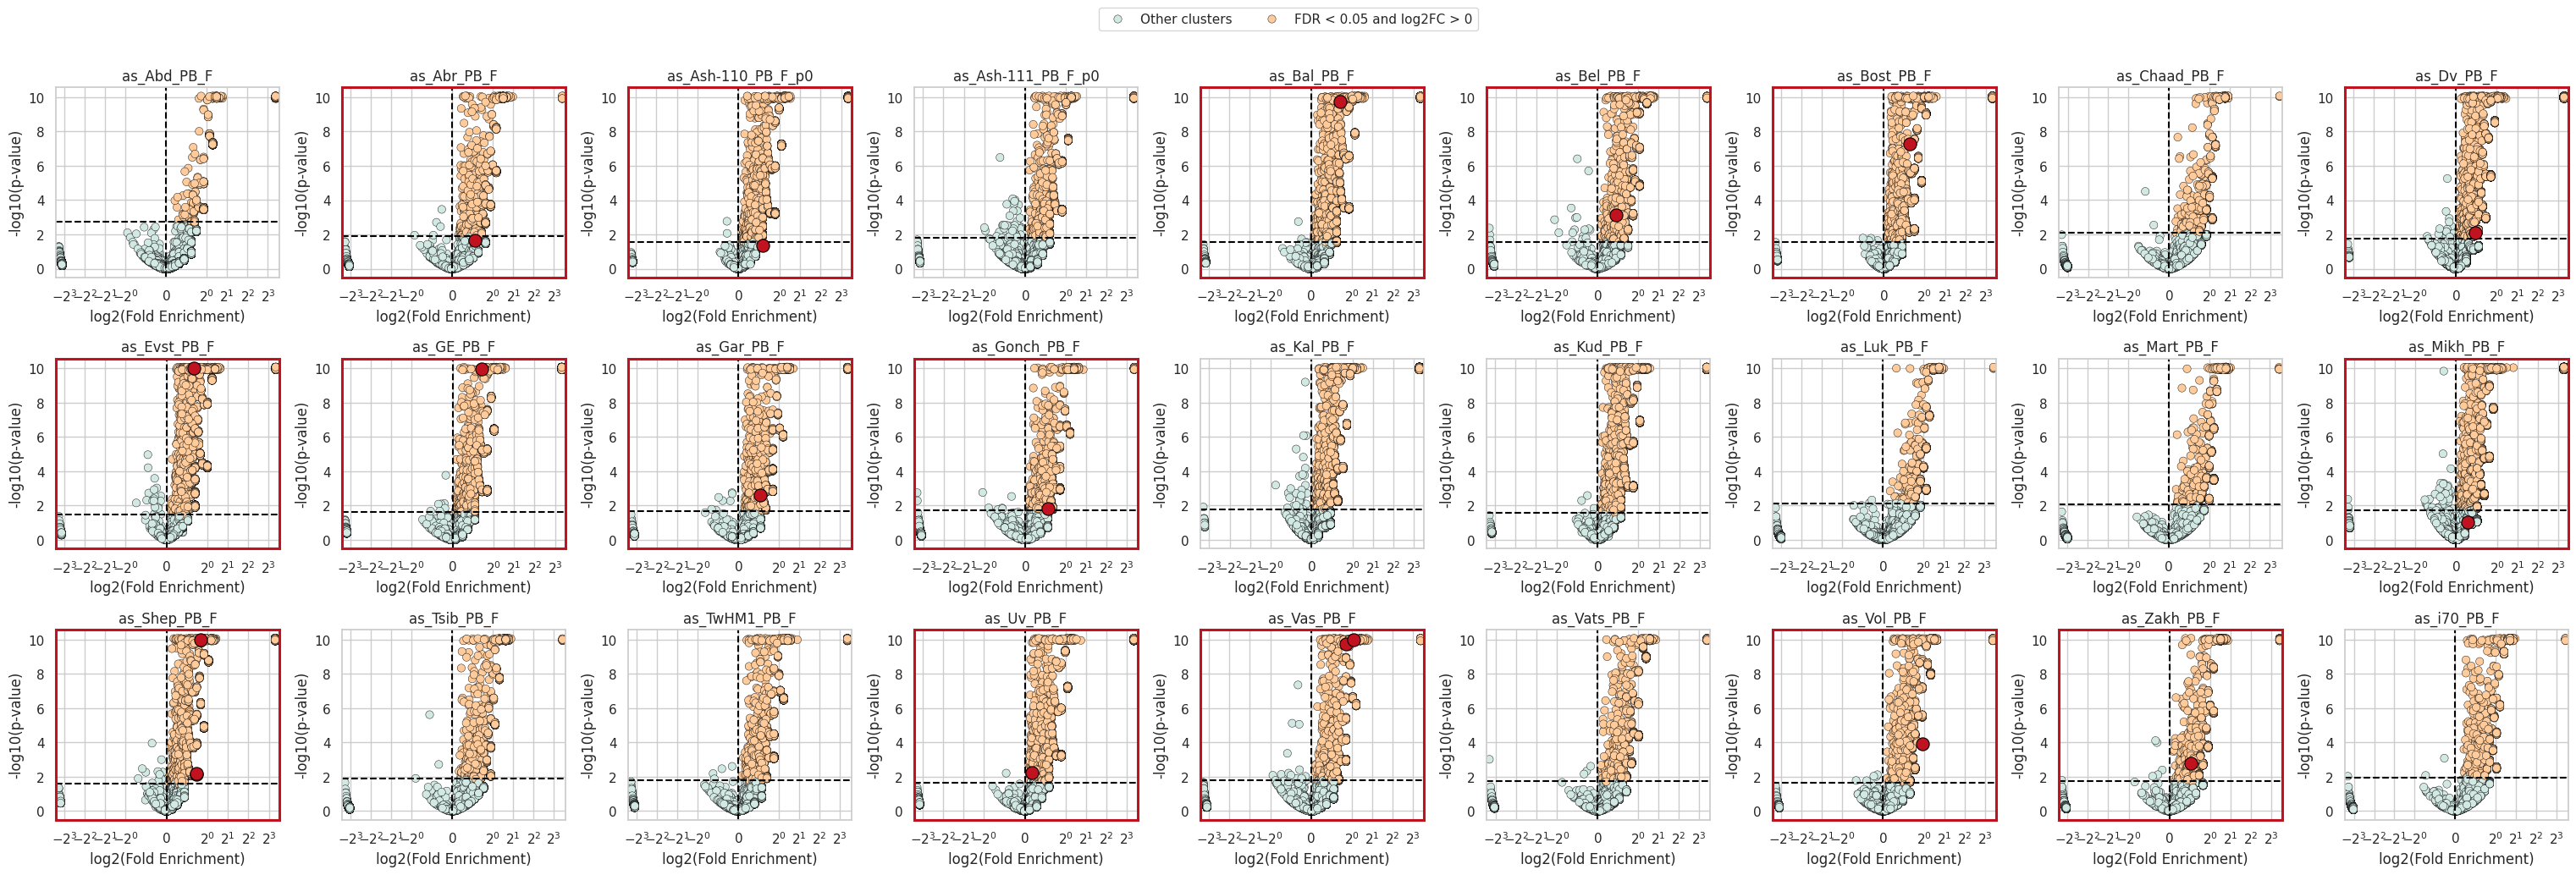

In [4]:
volcano_fig, volcano_summaries = plot_sample_volcano_grid(
    volcano_runs,
    matcher,
    fold_threshold=0,
    # pval_threshold=0.05,
    as_match_threshold=AS_MATCH_THRESHOLD,
)
plt.show()


In [5]:
merged_df = prepare_merged_clonotypes(
    all_runs,
    matcher,
    compute_pgen_if_missing=COMPUTE_PGEN_IF_MISSING,
    pgen_processes=PGEN_PROCESSES,
    as_match_threshold=AS_MATCH_THRESHOLD,
    case_regex=CASE_REGEX,
    control_regex=CONTROL_REGEX,
)

merged_df, merge_mapping = merge_clusters_by_cdr3_threshold(
    merged_df,
    substitutions=MERGE_SUBSTITUTIONS,
    cluster_col="cluster_uid",
    seq_col="cdr3aa_beta",
    merged_col="merged_cluster_id",
)

summary = summarize_merged_clusters(
    merged_df,
    external_control_usage=healthy_lookup,
    external_control_total=len(healthy_sample_names),
)
summary.head()


,merged_cluster_id,cluster_size,n_samples,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,patient_fc,log_patient_fc,log_pgen,log_cluster_size
0,0,194184,27,False,2.748783e-07,137227,56957,0.293315,0.706685,27,0,0.035714,3.0,0.477121,-6.560859,5.288213
1,74,184922,27,False,1.376184e-07,136994,47928,0.259180,0.740820,27,0,0.035714,3.0,0.477121,-6.861324,5.266989
2,98,44754,27,False,1.766920e-07,31008,13746,0.307146,0.692854,27,0,0.035714,3.0,0.477121,-6.752783,4.650832
3,76,31858,27,False,2.293889e-07,21608,10250,0.321740,0.678260,27,0,0.035714,3.0,0.477121,-6.639428,4.503219
4,37,18848,27,False,1.055895e-07,12675,6173,0.327515,0.672485,27,0,0.035714,3.0,0.477121,-6.976379,4.275265


In [6]:
summary[summary.as_pattern]

,merged_cluster_id,cluster_size,n_samples,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,patient_fc,log_patient_fc,log_pgen,log_cluster_size
162,2112,2381,20,True,2.013072e-08,1508,873,0.366653,0.633347,20,0,0.285714,2.481481,0.394711,-7.696141,3.376759
685,5892,64,6,True,2.049555e-08,31,33,0.515625,0.484375,6,0,1.000000,1.444444,0.159701,-7.688340,1.806180


In [7]:
ranked_df = rank_clusters_with_topsis(
    summary,
    min_samples=MIN_SAMPLES_FOR_RANKING,
    metric_types=TOPSIS_METRICS,
    weights=TOPSIS_WEIGHTS,
)

ranked_df[[
    "rank",
    "merged_cluster_id",
    "as_pattern",
    "cluster_size",
    "n_samples",
    "sample",
    "background",
    "sample_fraction",
    "as_usage",
    "h_usage",
    "fisher_p",
    "log_pgen",
    "patient_fc",
    "topsis_score",
]].head(30)


,rank,merged_cluster_id,as_pattern,cluster_size,n_samples,sample,background,sample_fraction,as_usage,h_usage,fisher_p,log_pgen,patient_fc,topsis_score
0,1,229,False,2121,27,889,1232,0.419142,27,0,0.035714,-7.345893,3.000000,0.671074
1,2,4,False,11034,27,3726,7308,0.337684,27,0,0.035714,-7.676489,3.000000,0.670733
2,3,288,False,4413,27,1698,2715,0.384772,27,0,0.035714,-7.289723,3.000000,0.665997
3,4,252,False,3202,26,1284,1918,0.400999,26,0,0.071429,-7.504317,2.925926,0.665343
4,5,35,False,7693,27,2783,4910,0.361757,27,0,0.035714,-7.219113,3.000000,0.661710
5,6,48,False,1702,26,773,929,0.454172,26,0,0.071429,-7.009498,2.925926,0.657968
6,7,7,False,12440,26,4383,8057,0.352331,26,0,0.071429,-7.351015,2.925926,0.656796
7,8,542,False,5733,26,2306,3427,0.402233,26,0,0.071429,-7.099153,2.925926,0.656540
8,9,27,False,8624,27,3008,5616,0.348794,27,0,0.035714,-7.097719,3.000000,0.656049
9,10,8,False,4261,27,1334,2927,0.313072,27,0,0.035714,-7.468505,3.000000,0.655317


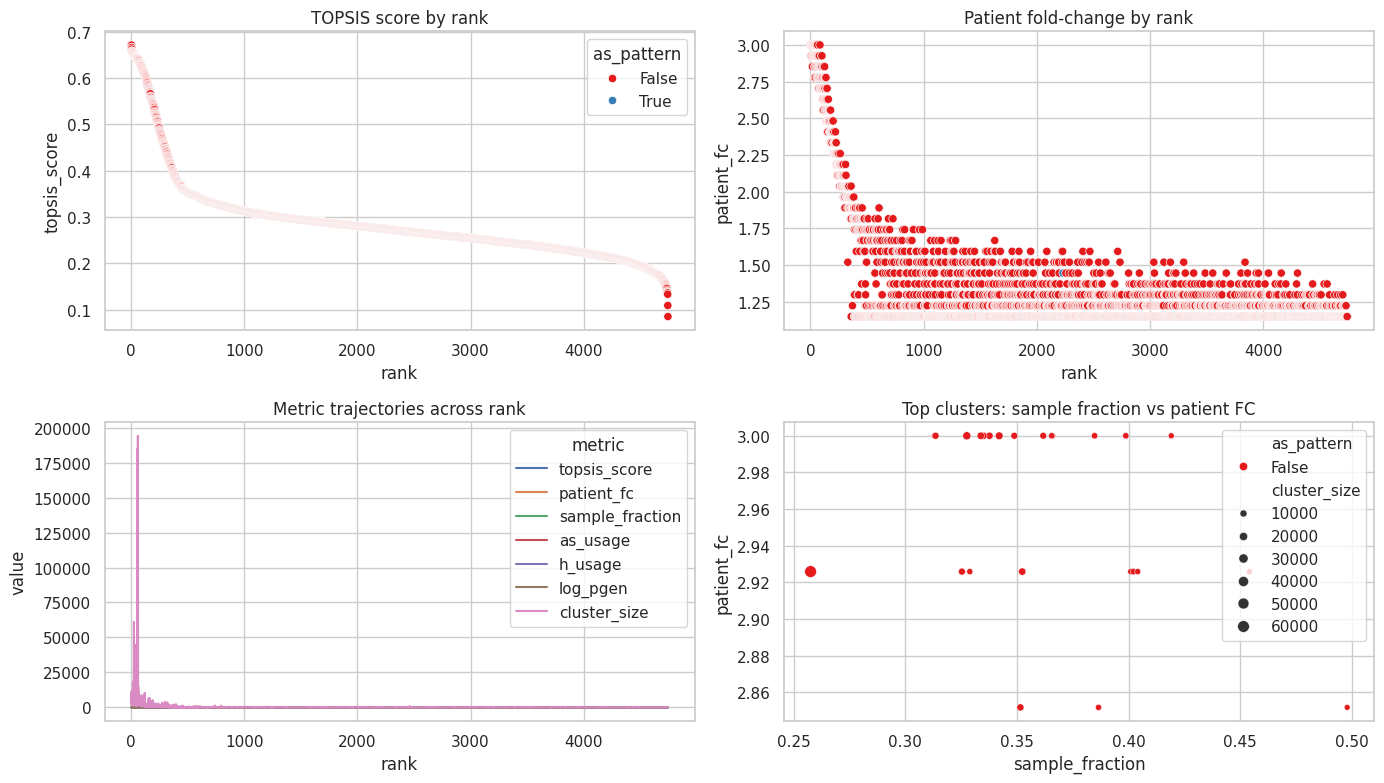

In [8]:
rank_fig = plot_ranked_metrics(ranked_df)
plt.show()


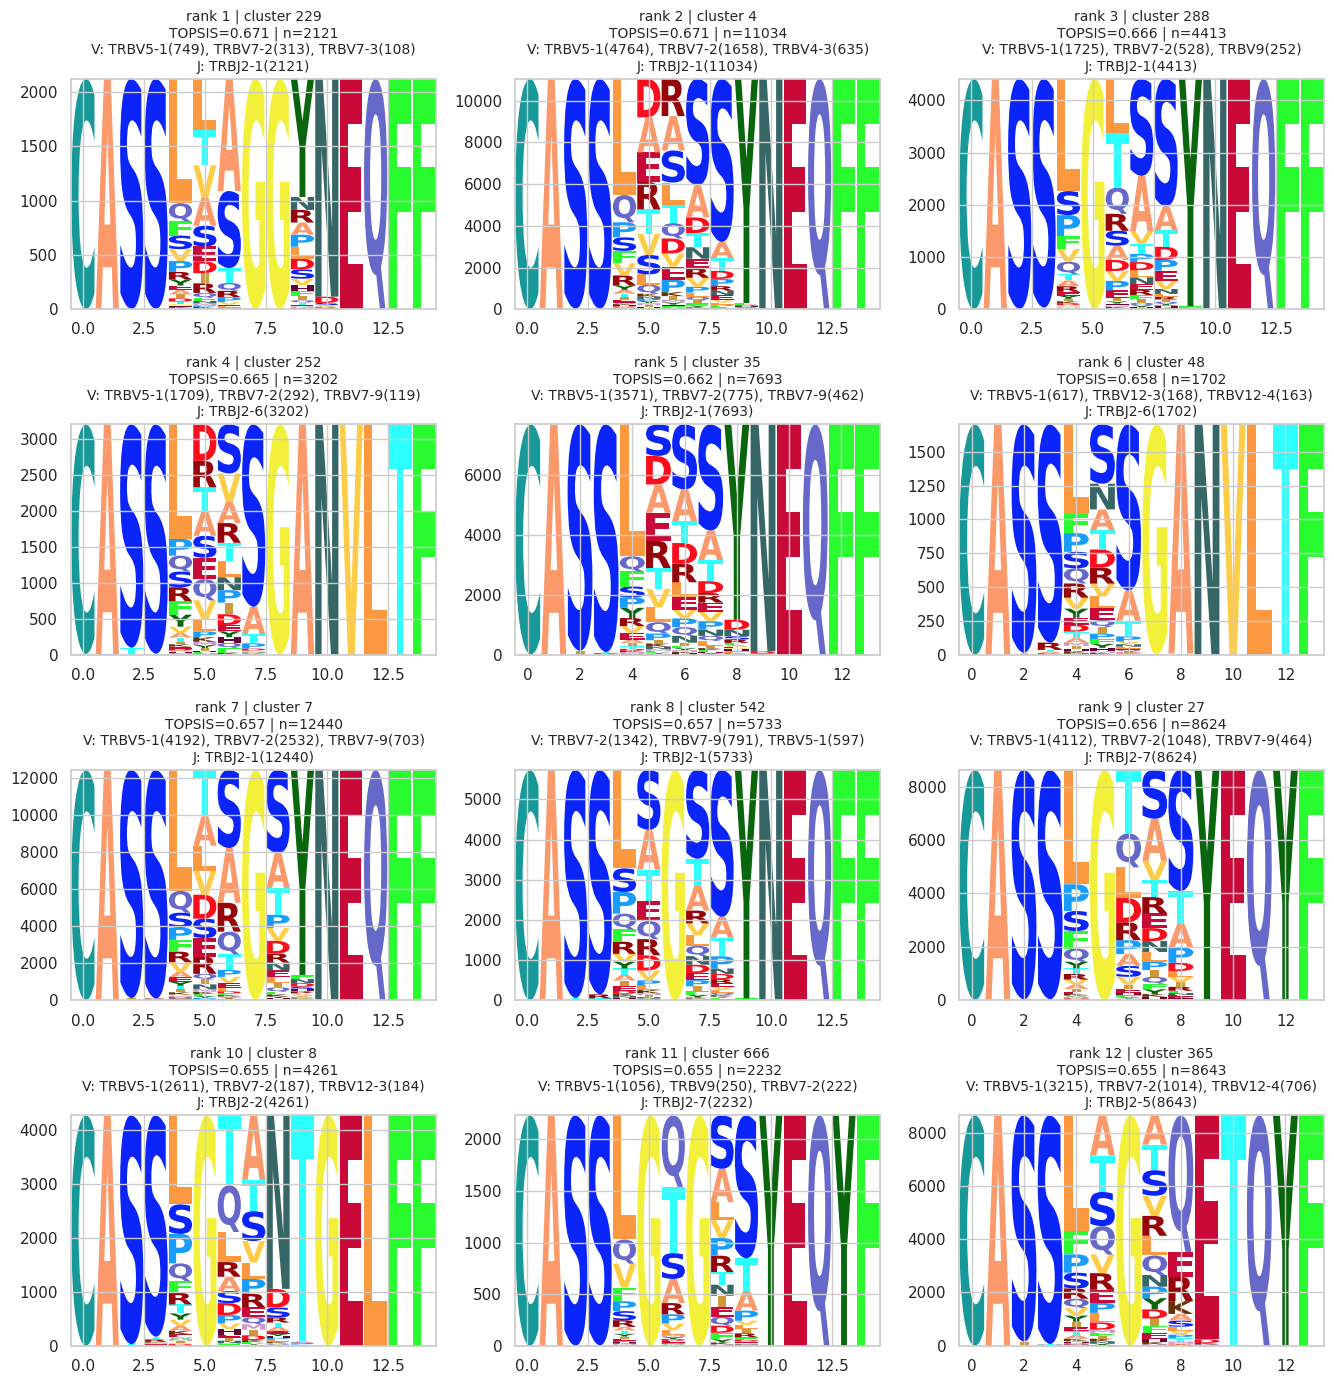

In [9]:
logo_fig = plot_top_cluster_logos(
    merged_df,
    ranked_df,
    top_n=TOP_N_LOGOS,
)
plt.show()
